# LLM SPICE-in-the-Loop: Comparator Optimization
This notebook demonstrates how to automatically loop the LLM with ngspice simulations (Delay, Offset, and PVT) to fix and tune a comparator.

In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import sys, os
from pathlib import Path
root = Path("/foss/designs/chipathon2026-D")
sys.path.insert(0, str(root))

from core import (
    generate_netlist_from_prompt,
    run_comparator_tran, run_comparator_pvt,
    spice_to_gds, display_component
)

In [74]:
# Check API Key
from core.pipeline import _load_api_key
key = _load_api_key()
if key:
    print(f"API key loaded: {key[:10]}...")
else:
    print("WARNING: DEEPSEEK_API_KEY not set!")

API key loaded: sk-81ba887...


In [78]:
prompt = """
Design a clocked StrongARM latch comparator.
Use gf180mcuD PDK with 1.8V supply.
The circuit should have:
- NMOS tail transistor controlled by clk
- NMOS differential input pair able for 10mV input offset voltage and W > 4u
- PMOS cross-coupled pair (W=4u L=0.5u)
- NMOS cross-coupled pair (W=3u L=0.5u)
- PMOS reset switches controlled by clk (W=2u L=0.5u)
- Output inverters (PMOS W=4u, NMOS W=2u, L=0.5u)
Subcircuit name: my_comp
Ports: vin_p, vin_n, clk, vout_p, vout_n, vdd, vss

this is the example of StrongArm latch comparator, you can use it as a reference for your design:

.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt comp_strongarm vin_p vin_n clk vout_p vout_n vdd vss
Mtail  n1 clk vss vss nfet_03v3 W=1u L=0.5u
M2 n2 vin_p n1 vss nfet_03v3 W=1u L=0.5u
M3 n3 vin_n n1 vss nfet_03v3 W=1u L=0.5u
M4 n2 n3 vdd vdd pfet_03v3 W=1u L=0.5u
M5 n3 n2 vdd vdd pfet_03v3 W=1u L=0.5u
M6 n2 n3 n1 vss nfet_03v3 W=1u L=0.5u
M7 n3 n2 n1 vss nfet_03v3 W=1u L=0.5u
M8 n2 clk vdd vdd pfet_03v3 W=1u L=0.5u
M9 n3 clk vdd vdd pfet_03v3 W=1u L=0.5u
M10 vout_p n2 vdd vdd pfet_03v3 W=1u L=0.5u
M11 vout_p n2 vss vss nfet_03v3 W=1u L=0.5u
M12 vout_n n3 vdd vdd pfet_03v3 W=1u L=0.5u
M13 vout_n n3 vss vss nfet_03v3 W=1u L=0.5u
.ends

Please generate the SPICE netlist for this comparator design based on the specifications provided above and make any necessary adjustments and improvements not copy and paste the example.
"""
print("Generating initial netlist...")
netlist = generate_netlist_from_prompt(prompt)
print("\n--- Initial Netlist ---\n", netlist)

Generating initial netlist...
[LLM] Response: 1149 bytes
[LLM] Raw (656 chars):
.lib "/path/to/gf180mcu/libs.tech/ngspice/sm141064.ngspice" typical
.subckt my_comp vin_p vin_n clk vout_p vout_n vdd vss
Mtail n1 clk vss vss nfet_03v3 W=5u L=1u
M2 n2 vin_p n1 vss nfet_03v3 W=5u L=1u
M3 n3 vin_n n1 vss nfet_03v3 W=5u L=1u
M4 n2 n3 vdd vdd pfet_03v3 W=4u L=0.5u
M5 n3 n2 vdd vdd pfe
[LLM] Cleaned (16 lines):
.lib "/path/to/gf180mcu/libs.tech/ngspice/sm141064.ngspice" typical
.subckt my_comp vin_p vin_n clk vout_p vout_n vdd vss
Mtail n1 clk vss vss nfet_03v3 W=5u L=1u
M2 n2 vin_p n1 vss nfet_03v3 W=5u L=1u
M3 n3 vin_n n1 vss nfet_03v3 W=5u L=1u
M4 n2 n3 vdd vdd pfet_03v3 W=4u L=0.5u
M5 n3 n2 vdd vdd pfet_03v3 W=4u L=0.5u
M6 n2 n3 n1 vss nfet_03v3 W=3u L=0.5u
M7 n3 n2 n1 vss nfet_03v3 W=3u L=0.5u
M8 n2 clk vdd vdd pfet_03v3 W=2u L=0.5u
M9 n3 clk vdd vdd pfet_03v3 W=2u L=0.5u
M10 vout_p n2 vdd vdd pfet_03v3 W=4u L=0.5u
M11 vout_p n2 vss vss nfet_03v3 W=2u L=0.5u
M12 vout_n n3 vdd vdd pfet_03v

In [79]:
max_iters = 10
iter_count = 0
finetune_needed = True
cell_name = "my_comp"

while finetune_needed and iter_count < max_iters:
    print(f"\n" + "="*40)
    print(f"=== SIMULATION ITERATION {iter_count} ===")
    print("="*40)
    
    if not netlist:
        print("No netlist to simulate. Aborting.")
        break
        
    # 1. Delay Simulation
    pre = run_comparator_tran(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=10e-9, tstop=30e-9)
    
    # 2. Offset Simulation
    off = run_comparator_tran(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=20e-9, tstop=100e-9, measure_offset=True)
    
    # 3. PVT Simulation
    pvt = run_comparator_pvt(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=10e-9, tstop=30e-9)
    
    # Evaluate combined finetune logic
    finetune_needed = pre.get('finetune', True) or off.get('finetune', True) or pvt.get('finetune', True)
    
    if not finetune_needed:
        print("\n>>> SUCCESS! The comparator is fully functional across all PVT corners. <<<")
        break
        
    print("\n[!] Comparator needs finetuning. Generating feedback for LLM...")
    # Generate a dummy testbench to show the LLM how the circuit is connected
    import tempfile
    from core.simulation import _generate_comparator_testbench
    tb_dummy = _generate_comparator_testbench(netlist, cell_name, tempfile.mkdtemp(), vdd=1.8, vcm=0.9, clk_period=10e-9, tstop=30e-9)
    try:
        with open(tb_dummy, 'r') as f:
            tb_content = f.read()
    except:
        tb_content = "Testbench unavailable."
        
    combined_feedback = (
        "=== SPICE TESTBENCH CONTEXT ===\n" + 
        "Here is the SPICE testbench used to evaluate your comparator. Please review how the pins (vin_p, vin_n, clk, vout_p, vout_n) are stimulated and connected to ensure your internal nodes respond correctly:\n" +
        f"```spice\n{tb_content}\n```\n\n" +

        "=== DELAY FEEDBACK ===\n" + pre.get("llm_feedback", "") + "\n\n" +
        "=== OFFSET FEEDBACK ===\n" + off.get("llm_feedback", "") + "\n\n" +
        "=== PVT FEEDBACK ===\n" + pvt.get("llm_feedback", "")
    )
    
    print(combined_feedback)
    print("\nAsking LLM for a revised netlist... Please wait.")
    
    # Feed the combined feedback back to the LLM to get a new netlist
    netlist = generate_netlist_from_prompt(prompt, llm_feedback=combined_feedback)
    iter_count += 1

if finetune_needed:
    print("\nWarning: Reached maximum iterations, but comparator might still have issues.")



=== SIMULATION ITERATION 0 ===
  [PVT] TT, 25°C, 1.80V ...
  [PVT] SS, 125°C, 1.62V ...
  [PVT] SS, -40°C, 1.62V ...
  [PVT] FF, -40°C, 1.98V ...
  [PVT] FF, 125°C, 1.98V ...
  [PVT] SF, 25°C, 1.80V ...
  [PVT] FS, 25°C, 1.80V ...
  [PVT] Offset measurement (TT, 25°C, 1.80V)...

[!] Comparator needs finetuning. Generating feedback for LLM...
=== SPICE TESTBENCH CONTEXT ===
Here is the SPICE testbench used to evaluate your comparator. Please review how the pins (vin_p, vin_n, clk, vout_p, vout_n) are stimulated and connected to ensure your internal nodes respond correctly:
```spice

* Comparator Transient Testbench — my_comp
.param fnoicor=0 sw_stat_global=0 sw_stat_mismatch=0
.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.include "/tmp/tmpraafwh04/my_comp_dut.spice"


.param VDD_VAL=1.8
.param VCM=0.9
.param VDELTA=0.01
.param CLK_PER=1e-08
.param CLK_PW=5e-09
.param CLK_RISE=1e-10

VDD  n_vdd  0 DC {VDD_VAL}
VSS  n_vss  0 DC 0

Vclk n_clk 0 PULSE(0 {V

Generating layout for the functional comparator...
[PIPELINE] PDK: gf180
{'name': 'tie_W_top_met_W', 'width': 9.81, 'center': [-5.22, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan Mtail (nfet_03v3) di posisi X: 0.0u, Y: 0.0u
{'name': 'tie_W_top_met_W', 'width': 11.81, 'center': [18.63, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan M2 (nfet_03v3) di posisi X: 23.849999999999998u, Y: 0.0u
{'name': 'tie_W_top_met_W', 'width': 11.81, 'center': [42.48, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan M3 (nfet_03v3) di posisi X: 47.699999999999996u, Y: 0.0u
[LAYOUT] Sukses menempatkan M4 (pfet_03v3) di posisi X: 16.425000000000004u, Y: 47.0u
[LAYOUT] Sukses menempatkan M5 (pfet_03v3) di posisi X: 35.775000000000006u, Y: 47.0u
{'name': 'tie_W_top_met_W', 'width': 6.81, 'center': [67.075, 0.0], 'orientation': 180.0, 'layer': [34, 0], 

2026-07-04 20:22:54.598 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/optimized_comparator.gds'
2026-07-04 20:22:54.609 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/out.gds'


[PIPELINE] 7 pin labels added
[PIPELINE] Done: my_comp
Layout written to /home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/optimized_comparator.gds


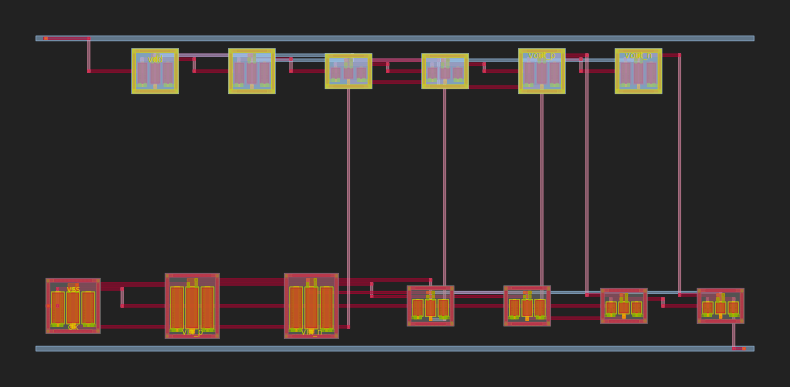

In [80]:
# If we achieved a good netlist, generate the final GDS
if not finetune_needed and netlist:
    print("Generating layout for the functional comparator...")
    GDS_PATH = os.path.join(os.getcwd(), "optimized_comparator.gds")
    result = spice_to_gds(netlist, mode="analog", add_labels=True)
    result.write_gds(GDS_PATH)
    print(f"Layout written to {GDS_PATH}")
    display_component(result, scale=0.5)
